In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sharedfunctions import loadKernels, computeSigma, computeMagnitudeResponse, calculateEcc, eccL2Distance, eccWassersteinDistance, IDXROBUST, IDXVULNERABLE, GRIDSIZE, SIGMAGRID, NTHRESH, CSVPATH

In [2]:
kernels = loadKernels(CSVPATH)

In [3]:
def generateVPWaveletKernel():
    n=3
    nodes = np.cos(np.pi * np.arange(1, 2*n, 2) / (2*n))
    vp2d = np.outer(nodes, nodes)
    vp2d = vp2d - vp2d.mean()
    vp2d = vp2d / np.max(np.abs(vp2d))
    return vp2d.astype(np.float32)
vp = generateVPWaveletKernel()   
magVp = computeMagnitudeResponse(vp)
_, eccVp = calculateEcc(magVp)

In [4]:
np.random.seed(0)
randomIndices = np.random.choice(
    [i for i in range(len(kernels)) if i not in [IDXROBUST, IDXVULNERABLE]],
    size=48, replace=False)
allIndices = np.array([IDXROBUST, IDXVULNERABLE] + list(randomIndices))


eccs   = []
sigmas = []
for idx in allIndices:
    h = kernels[idx]
    mag = computeMagnitudeResponse(h)
    _, ecc = calculateEcc(mag)
    eccs.append(ecc)
    sigmas.append(computeSigma(h))
eccs   = np.array(eccs)
sigmas = np.array(sigmas)

l2toVp    = np.array([eccL2Distance(e, eccVp) for e in eccs])
wasstoVp  = np.array([eccWassersteinDistance(e, eccVp) for e in eccs])
distMatrix = cdist(eccs, eccs, metric='euclidean')


In [5]:
corr = np.corrcoef(sigmas, l2toVp)[0, 1]
print(f"\nPearson r (sigma vs L2 to VP): {corr:.4f}")
print(f"(Negative = higher sigma -> closer to VP = more robust)\n")
print(f"{'Kernel':>8} {'sigma':>10} {'L2 to VP':>12} {'Wasserstein':>14}")
for i in np.argsort(l2toVp)[:10]:
    k   = allIndices[i]
    tag = " <- ROBUST"     if k == IDXROBUST     else \
          " <- VULNERABLE" if k == IDXVULNERABLE else ""
    print(f"{k:>8} {sigmas[i]:>10.6f} {l2toVp[i]:>12.4f} {wasstoVp[i]:>14.4f}{tag}")



Pearson r (sigma vs L2 to VP): -0.2021
(Negative = higher sigma -> closer to VP = more robust)

  Kernel      sigma     L2 to VP    Wasserstein
    3934   0.006619      20.0250         4.9991
    1453   0.002243      22.9565         1.3939
     583   0.000000      23.6008         1.0785
    3843   0.004891      23.7065        10.9511
      88   0.009338      24.3516        19.1711
      42   0.414453      24.5764         5.1063 <- ROBUST
    2811   0.003339      26.3059         3.0330
    2207   0.001662      26.5895         4.3881
    3195   0.002290      26.9815         7.5077
     312   0.007730      28.8097         7.7593


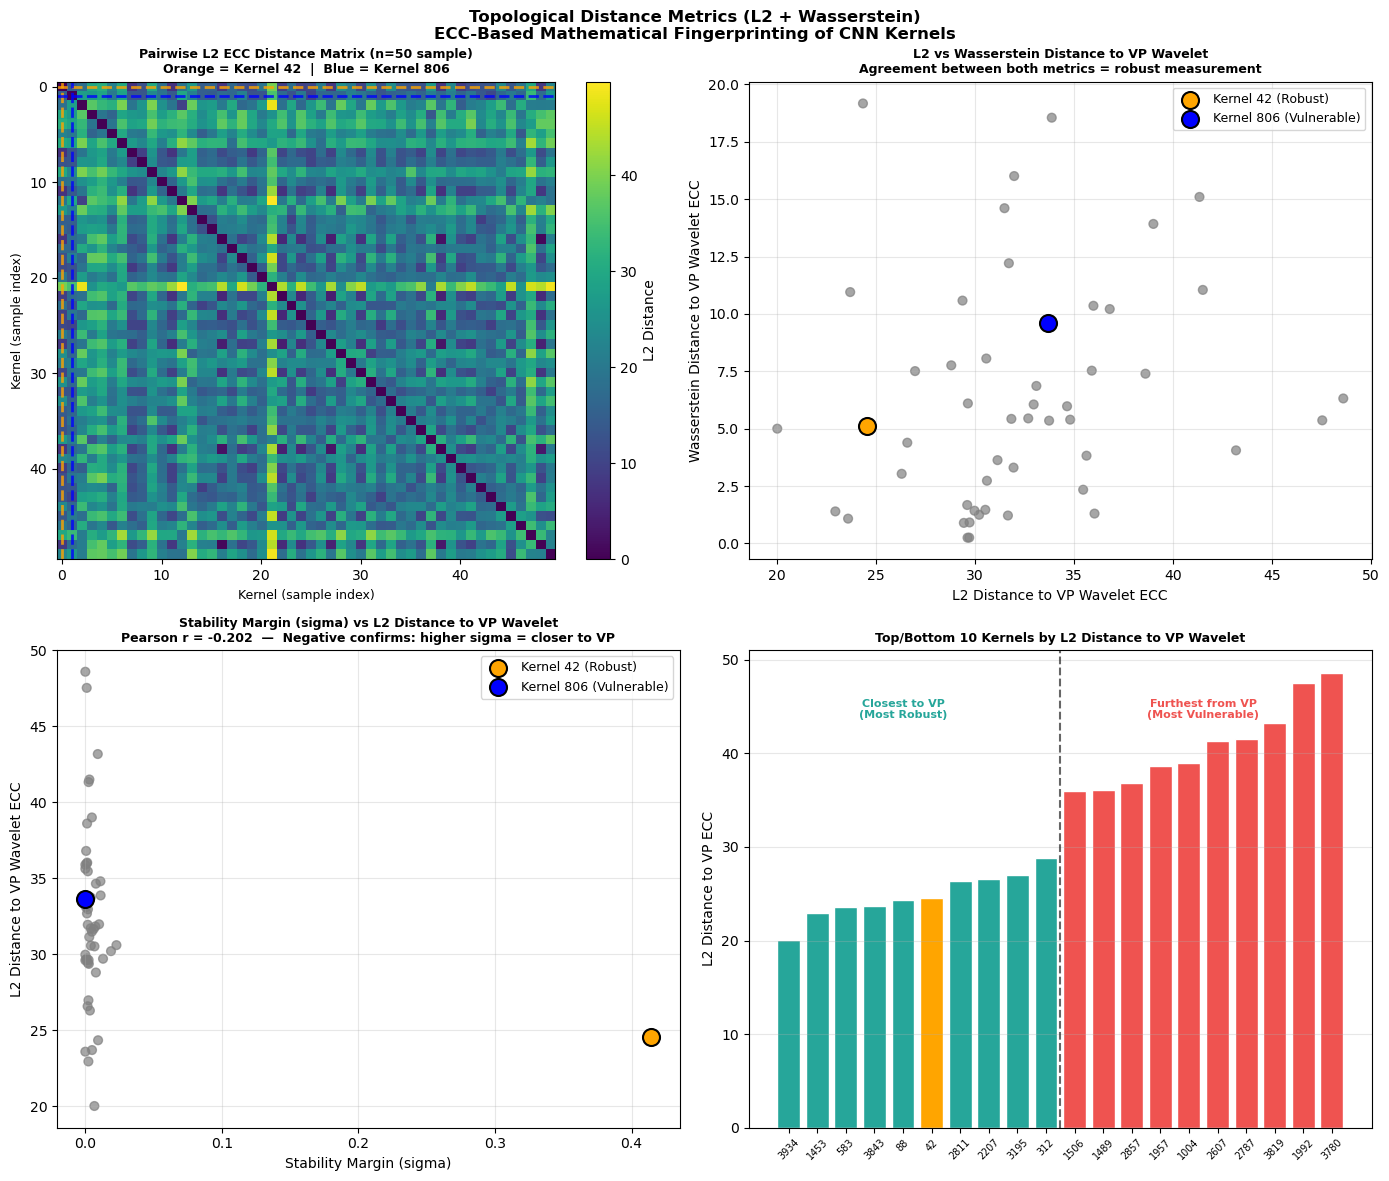

In [6]:
scatter_colors = ['orange' if idx == IDXROBUST else
                   'blue'   if idx == IDXVULNERABLE else
                   'gray' for idx in allIndices]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Topological Distance Metrics (L2 + Wasserstein)\n"
             "ECC-Based Mathematical Fingerprinting of CNN Kernels",
             fontsize=12, fontweight='bold')

ax = axes[0, 0]
im = ax.imshow(distMatrix, cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax, label='L2 Distance')
ax.axhline(0, color='orange', linewidth=2, linestyle='--', alpha=0.8)
ax.axvline(0, color='orange', linewidth=2, linestyle='--', alpha=0.8)
ax.axhline(1, color='blue',   linewidth=2, linestyle='--', alpha=0.8)
ax.axvline(1, color='blue',   linewidth=2, linestyle='--', alpha=0.8)
ax.set_title(f"Pairwise L2 ECC Distance Matrix (n=50 sample)\n"
             f"Orange = Kernel {IDXROBUST}  |  Blue = Kernel {IDXVULNERABLE}",
             fontsize=9, fontweight='bold')
ax.set_xlabel("Kernel (sample index)", fontsize=9)
ax.set_ylabel("Kernel (sample index)", fontsize=9)


ax = axes[0, 1]
ax.scatter(l2toVp, wasstoVp, c=scatter_colors, alpha=0.7, s=40)
ax.scatter(l2toVp[0], wasstoVp[0], c='orange', s=150, zorder=5,
           edgecolors='black', linewidths=1.5,
           label=f'Kernel {IDXROBUST} (Robust)')
ax.scatter(l2toVp[1], wasstoVp[1], c='blue',   s=150, zorder=5,
           edgecolors='black', linewidths=1.5,
           label=f'Kernel {IDXVULNERABLE} (Vulnerable)')
ax.set_title("L2 vs Wasserstein Distance to VP Wavelet\n"
             "Agreement between both metrics = robust measurement",
             fontsize=9, fontweight='bold')
ax.set_xlabel("L2 Distance to VP Wavelet ECC", fontsize=10)
ax.set_ylabel("Wasserstein Distance to VP Wavelet ECC", fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.scatter(sigmas, l2toVp, c=scatter_colors, alpha=0.7, s=40)
ax.scatter(sigmas[0], l2toVp[0], c='orange', s=150, zorder=5,
           edgecolors='black', linewidths=1.5,
           label=f'Kernel {IDXROBUST} (Robust)')
ax.scatter(sigmas[1], l2toVp[1], c='blue',   s=150, zorder=5,
           edgecolors='black', linewidths=1.5,
           label=f'Kernel {IDXVULNERABLE} (Vulnerable)')
ax.set_title(f"Stability Margin (sigma) vs L2 Distance to VP Wavelet\n"
             f"Pearson r = {corr:.3f}  —  Negative confirms: higher sigma = closer to VP",
             fontsize=9, fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)", fontsize=10)
ax.set_ylabel("L2 Distance to VP Wavelet ECC", fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
order = np.argsort(l2toVp)
top10 = order[:10]; bot10 = order[-10:]
show  = np.concatenate([top10, bot10])
bar_colors = ['orange' if allIndices[i] == IDXROBUST else
               'blue'   if allIndices[i] == IDXVULNERABLE else
               '#26a69a' if i in top10 else '#ef5350'
               for i in show]
ax.bar(range(len(show)), l2toVp[show], color=bar_colors, edgecolor='white')
ax.axvline(9.5, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
ymax = max(l2toVp[show])
ax.text(4,    ymax*0.9, 'Closest to VP\n(Most Robust)',
        ha='center', fontsize=8, color='#26a69a', fontweight='bold')
ax.text(14.5, ymax*0.9, 'Furthest from VP\n(Most Vulnerable)',
        ha='center', fontsize=8, color='#ef5350', fontweight='bold')
ax.set_xticks(range(len(show)))
ax.set_xticklabels([str(allIndices[i]) for i in show], rotation=45, fontsize=7)
ax.set_title("Top/Bottom 10 Kernels by L2 Distance to VP Wavelet",
             fontsize=9, fontweight='bold')
ax.set_ylabel("L2 Distance to VP ECC", fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("TopologicalDistanceMetrics.png", dpi=150, bbox_inches='tight')
plt.show()